In [24]:
import numpy as np
import yaml
import os
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
result_dir = "test_collection"

In [26]:
result_list = []
trials = []
for file in os.listdir(result_dir):
    if file.startswith("trial"):
        with open(os.path.join(result_dir,file),"r") as result_file:
            trials.append(file.split("_")[1])
            results = yaml.safe_load(result_file)
            result_list.append(results)
result_df = pd.DataFrame(result_list) 
result_df.index = trials


In [27]:
print(result_df)

      accidents  distance_traveled   env  nav_type  obstacles_encountered
0001          0          49.121767  base  distance                      0
0002          0          49.098919  base  distance                      0
0003          0          49.076072  base  distance                      0
0004          0          49.167461  base  distance                      0
0005          0          49.098919  base  distance                      0
...         ...                ...   ...       ...                    ...
0096          0          49.030377  base  distance                      0
0097          0          49.098919  base  distance                      0
0098          0          49.121767  base  distance                      0
0099          0          49.076072  base  distance                      0
0100          0          49.213156  base  distance                      0

[100 rows x 5 columns]


In [ ]:
total_trials = len(result_df)
print("Total Trials:",total_trials)

Total Trials: 100
Total Distance: 4910.782979333333


In [54]:
summary_df = result_df.groupby(["nav_type","env"]).agg({"accidents":"mean","distance_traveled":"sum","obstacles_encountered":"mean"}).reset_index()

In [55]:
summary_df["trials"] = total_trials

In [56]:
summary_df["acc_rate"] = (summary_df.accidents * 100) / summary_df.distance_traveled

In [66]:
summary_df.nav_type = summary_df.nav_type.str.capitalize()
summary_df.env = summary_df.env.str.capitalize()

In [67]:
print(summary_df)

   nav_type   env  accidents  distance_traveled  obstacles_encountered  \
0  Distance  Base        0.0        4910.782979                    0.0   

   trials  acc_rate  
0     100       0.0  


In [ ]:
# dummy data
summary_df = pd.DataFrame([{"nav":"Distance","env":"Base","trials":"Placeholder","dist":"Placeholder","avg_obs":"Placeholder","acc_rate":"Placeholder"},
                           {"nav":"Distance","env":"Train","trials":"Placeholder","dist":"Placeholder","avg_obs":"Placeholder","acc_rate":"Placeholder"}])

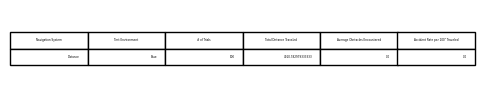

In [68]:
fig, ax = plt.subplots(figsize=(6, 1)) 
ax.axis('off')
ax.table(cellText=np.array(summary_df[["nav_type","env","trials","distance_traveled","obstacles_encountered","acc_rate"]]), colLabels=["Navigation System","Test Environment", "# of Trials","Total Distance Traveled","Average Obstacles Encountered","Accident Rate per 100\" Traveled"], loc='center')

plt.savefig("result_table.png", dpi=300)

In [69]:
plt.clf()

<Figure size 640x480 with 0 Axes>

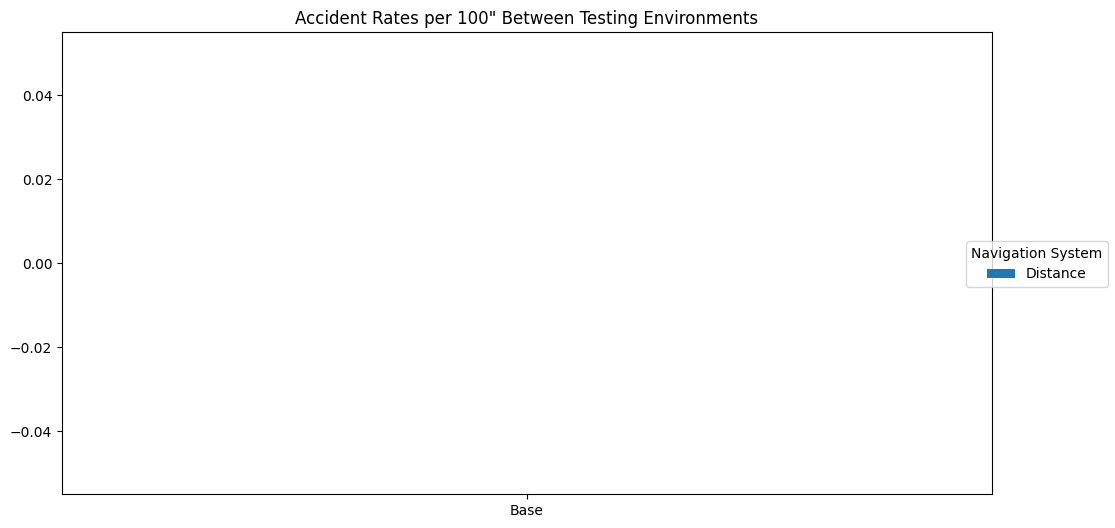

In [71]:
fig, ax = plt.subplots(figsize=(12, 6))


ax.bar(summary_df.env,summary_df.acc_rate,label=summary_df.nav_type)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(),loc='outside right center',title="Navigation System")

ax.set_title("Accident Rates per 100\" Between Testing Environments")
#fig.legend()
plt.savefig("result_bar.png", dpi=300)